
# Sesión 02 — Modelos de Clasificación
**Ingeniería del Conocimiento (ISO56B)** · UNCP · 2026-II

**Docente:** Msc. Jaime Antonio Huaytalla Pariona

**Dataset:** Breast Cancer Wisconsin (569 muestras, 30 features, clasificación binaria)

---

## 1. Configuración del entorno

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    ConfusionMatrixDisplay, RocCurveDisplay
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

El dataset **Breast Cancer Wisconsin** contiene 569 muestras de biopsias de mama con 30 features numéricas computadas a partir de imágenes digitalizadas de aspiración con aguja fina (FNA). El target es binario: **maligno (0)** o **benigno (1)**.

In [ ]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'maligno', 1: 'benigno'})

print(f'Dataset: {df.shape[0]} muestras, {df.shape[1]-2} features')
print(f'\nDistribución de clases:')
print(df['diagnosis'].value_counts())
print(f'\nProporción: {df["target"].mean():.1%} benigno, {1-df["target"].mean():.1%} maligno')

Dataset: 569 muestras, 30 features

Distribución de clases:
diagnosis
benigno    357
maligno    212
Name: count, dtype: int64

Proporción: 62.7% benigno, 37.3% maligno


In [ ]:
df.describe().round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


---
## 3. Análisis exploratorio orientado a clasificación

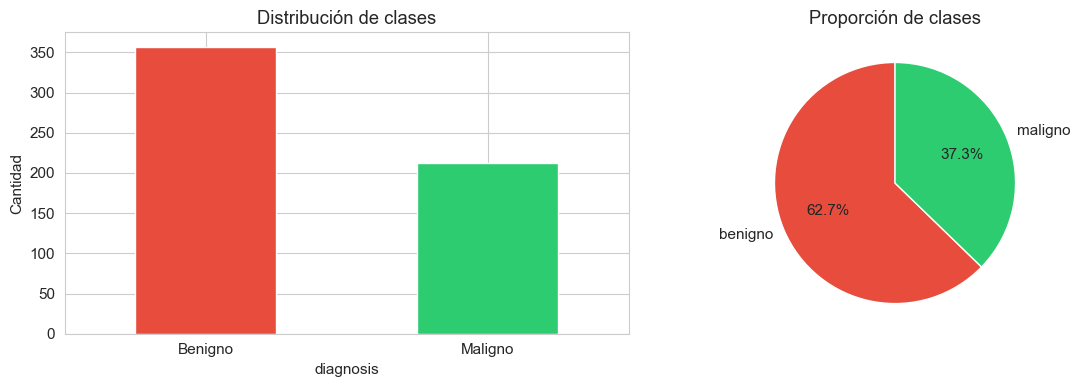

In [ ]:
# 3.1  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
colors = ['#e74c3c', '#2ecc71']
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Benigno', 'Maligno'], rotation=0)

# Pie chart
df['diagnosis'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

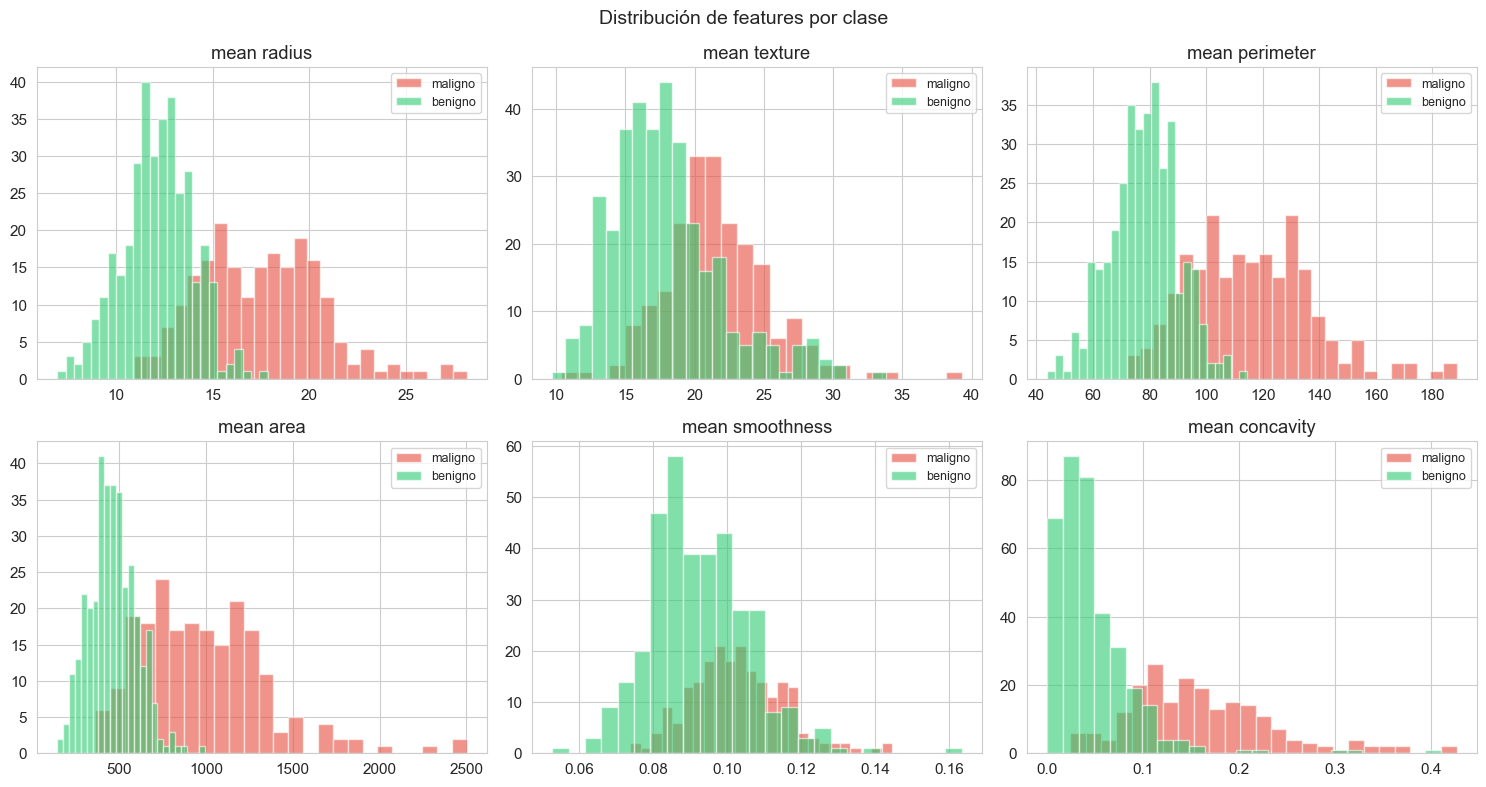

In [ ]:
# 3.2  Distribución de features clave por clase
key_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(key_features):
    ax = axes[i//3, i%3]
    for label, color in zip([0, 1], colors):
        subset = df[df['target'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='maligno' if label == 0 else 'benigno')
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

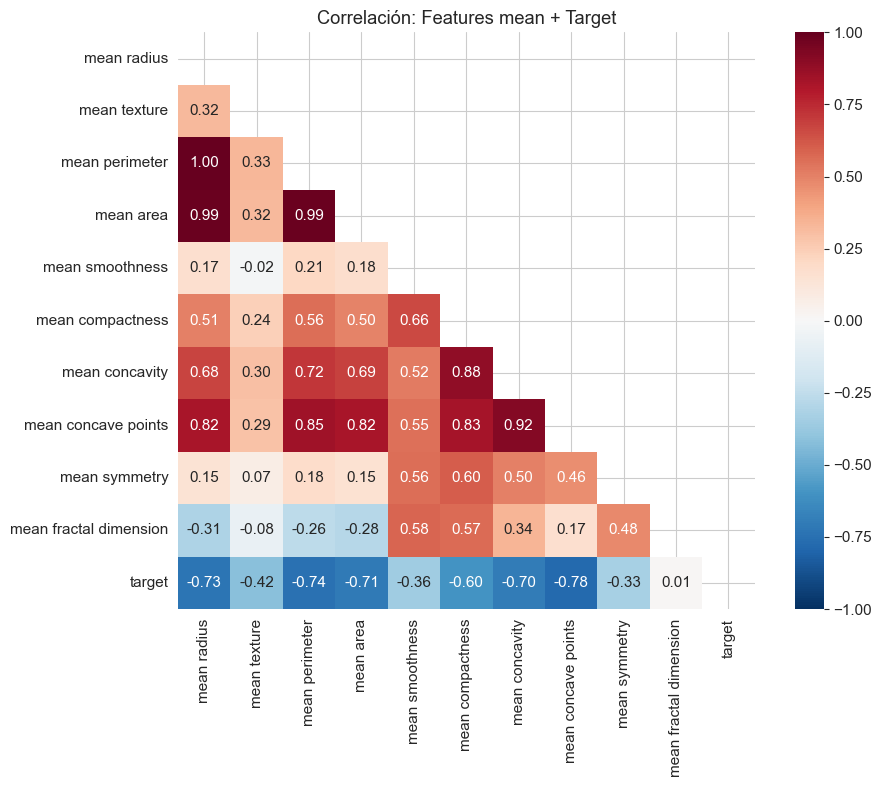

In [ ]:
# 3.3  Matriz de correlación (features mean)
mean_features = [c for c in df.columns if 'mean' in c]
plt.figure(figsize=(10, 8))
corr = df[mean_features + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación: Features mean + Target')
plt.tight_layout()
plt.show()

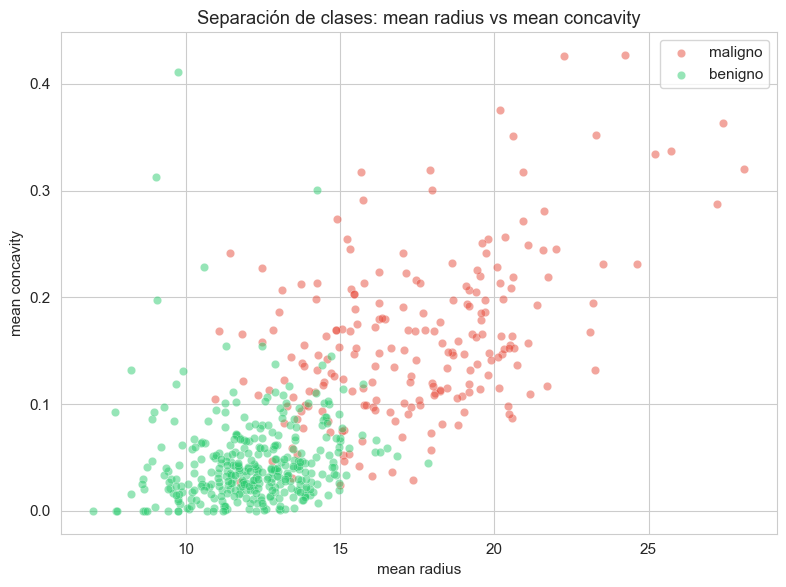

In [ ]:
# 3.4  Scatter plot: 2 features más discriminativas
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], colors, ['maligno', 'benigno']):
    mask = df['target'] == label
    ax.scatter(df.loc[mask, 'mean radius'], df.loc[mask, 'mean concavity'],
              alpha=0.5, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xlabel('mean radius')
ax.set_ylabel('mean concavity')
ax.set_title('Separación de clases: mean radius vs mean concavity')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [ ]:
X = df[data.feature_names].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'\nProporción en train: {y_train.mean():.1%} benigno')
print(f'Proporción en test:  {y_test.mean():.1%} benigno')

# Stratified K-Fold para validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Entrenamiento: 455 muestras
Test:          114 muestras

Proporción en train: 62.6% benigno
Proporción en test:  63.2% benigno


### Funciones auxiliares para evaluación de clasificadores

In [ ]:
def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    """Evalúa un clasificador: métricas, matriz de confusión y reporte."""
    y_pred = model.predict(X_te)

    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred)
    }

    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')

    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Maligno', 'Benigno'],
                yticklabels=['Maligno', 'Benigno'])
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    # Desglose FP y FN
    tn, fp, fn, tp = cm.ravel()
    labels = ['TN\n(benigno\ncorrecto)', 'FP\n(benigno→\nmaligno)',
              'FN\n(maligno→\nbenigno)', 'TP\n(maligno\ncorrecto)']
    values = [tn, fp, fn, tp]
    bar_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    axes[1].bar(labels, values, color=bar_colors)
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')

    plt.tight_layout()
    plt.show()

    print(f'\n  FN (maligno no detectado): {fn}')
    print(f'  FP (benigno como maligno): {fp}')
    print(f'\nReporte completo:')
    print(classification_report(y_te, y_pred,
          target_names=['maligno', 'benigno']))

    return metrics


def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    """Genera la curva ROC de un modelo."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        print(f'{model_name}: no soporta probabilidades')
        return None

    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, linewidth=2,
            label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {model_name}')
    ax.legend()

    return roc_auc

---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=1|x) mediante la función sigmoide σ(z) = 1/(1+e^(−z)). La frontera de decisión es lineal en el espacio de features. Se optimiza minimizando la Log-Loss (entropía cruzada binaria) con regularización L2 por defecto.

In [ ]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Validación cruzada estratificada
cv_lr = cross_validate(pipe_lr, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr["test_accuracy"].mean():.4f} ± {cv_lr["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr["test_f1"].mean():.4f} ± {cv_lr["test_f1"].std():.4f}')
print(f'  Recall:    {cv_lr["test_recall"].mean():.4f} ± {cv_lr["test_recall"].std():.4f}')

# Entrenar modelo final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.9780 ± 0.0098
  F1-Score:  0.9825 ± 0.0078
  Recall:    0.9860 ± 0.0131


=== Regresión Logística ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


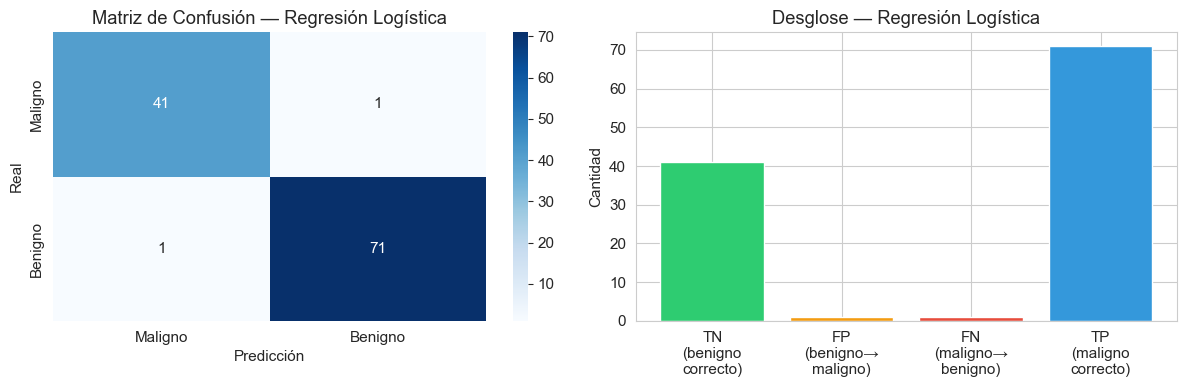


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
# 5.2  Evaluación completa
metrics_lr = eval_classifier(pipe_lr, X_train, y_train, X_test, y_test,
                             'Regresión Logística')

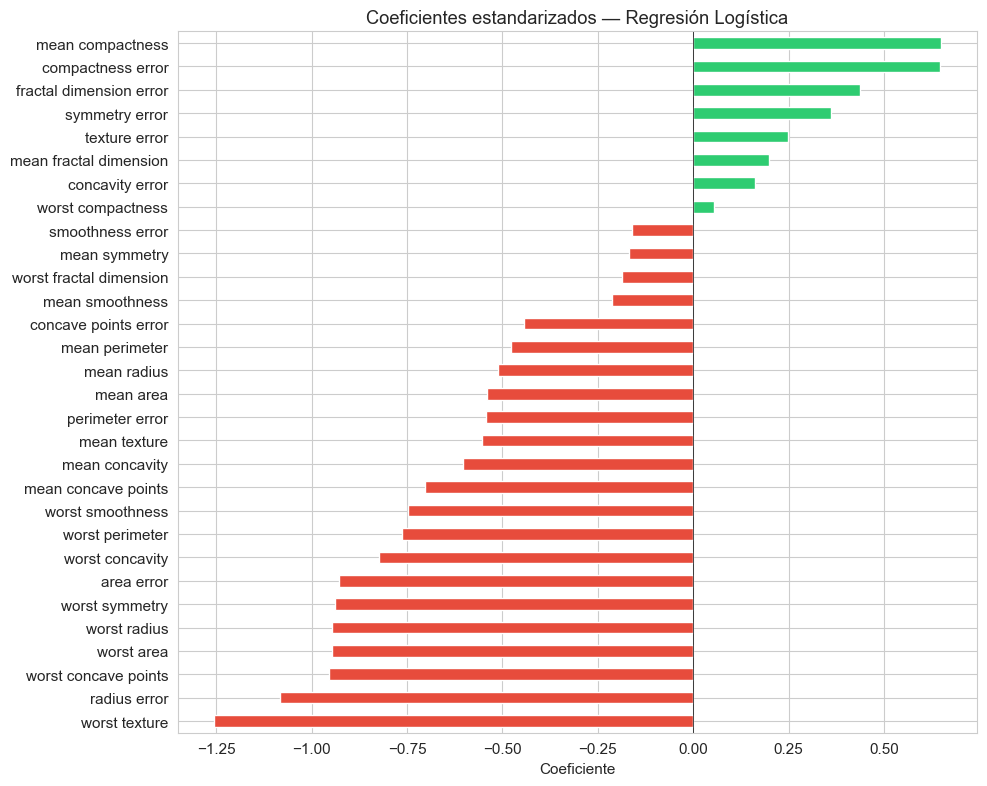

Interpretación:
  → Features que más indican MALIGNO: ['worst texture', 'radius error', 'worst concave points']
  → Features que más indican BENIGNO: ['fractal dimension error', 'compactness error', 'mean compactness']


In [ ]:
# 5.3  Coeficientes estandarizados
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=data.feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Coeficientes estandarizados — Regresión Logística')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican MALIGNO: {coefs.head(3).index.tolist()}')
print(f'  → Features que más indican BENIGNO: {coefs.tail(3).index.tolist()}')

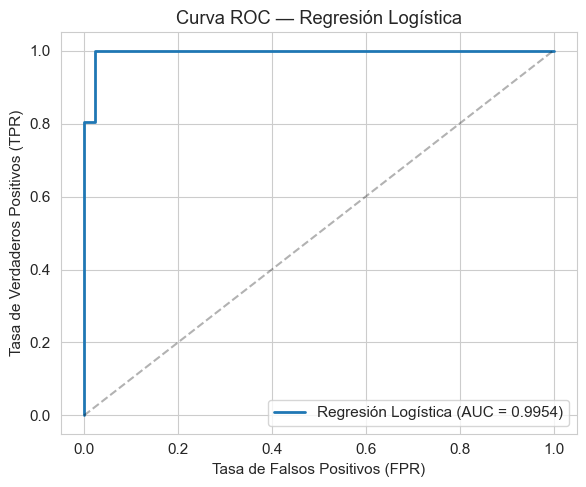

AUC: 0.9954


In [ ]:
# 5.4  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(pipe_lr, X_test, y_test, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr:.4f}')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** CART construye particiones recursivas del espacio de features. En cada nodo selecciona la feature y el umbral que maximizan la reducción de impureza (Gini: G(t) = 1 − Σpₖ²). Las particiones son ortogonales a los ejes.

In [ ]:
# 6.1  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full = cross_validate(pipe_dt_full, X_train, y_train, cv=skf,
                            scoring=['accuracy', 'f1', 'recall'],
                            return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full["test_accuracy"].mean():.4f} ± {cv_dt_full["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full["test_f1"].mean():.4f} ± {cv_dt_full["test_f1"].std():.4f}')
print(f'\n⚠ Train accuracy ~1.0 indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Test Accuracy:  0.9165 ± 0.0179
  Test F1-Score:  0.9319 ± 0.0144

⚠ Train accuracy ~1.0 indica sobreajuste


In [ ]:
# 6.2  Árbol con pre-poda
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt["test_accuracy"].mean():.4f} ± {cv_dt["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt["test_f1"].mean():.4f} ± {cv_dt["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_dt["test_recall"].mean():.4f} ± {cv_dt["test_recall"].std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.9747
  Test Accuracy:  0.9275 ± 0.0226
  Test F1-Score:  0.9417 ± 0.0189
  Test Recall:    0.9368 ± 0.0325


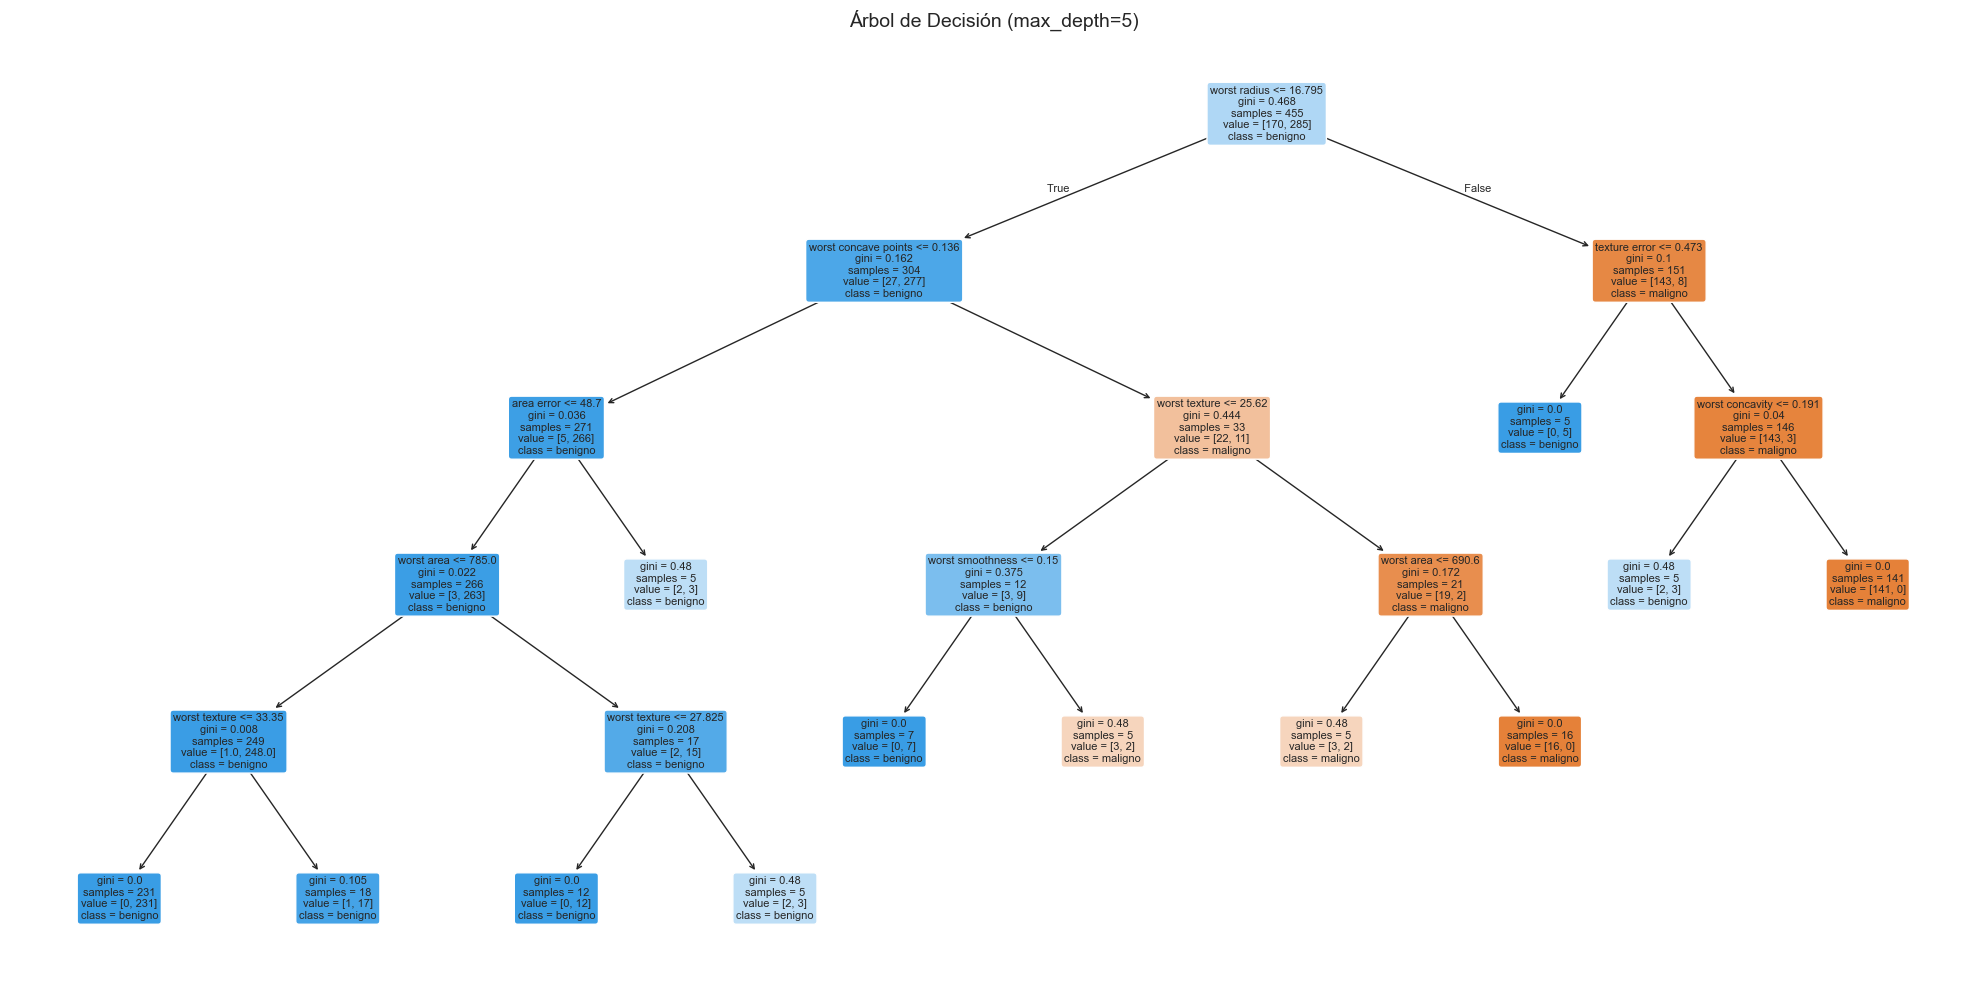

In [ ]:
# 6.3  Visualización del árbol podado
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt.named_steps['clf'],
          feature_names=data.feature_names,
          class_names=['maligno', 'benigno'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.9211
  Precision: 0.9437
  Recall: 0.9306
  F1-Score: 0.9371


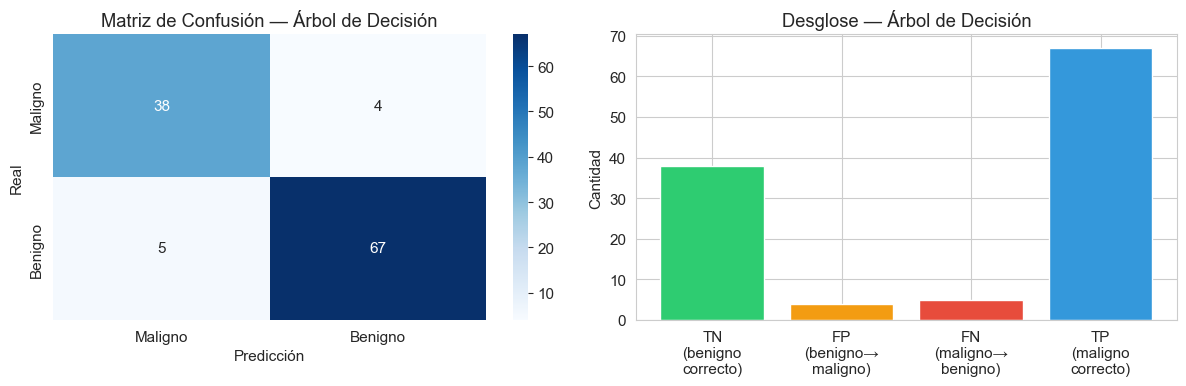


  FN (maligno no detectado): 5
  FP (benigno como maligno): 4

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.88      0.90      0.89        42
     benigno       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [ ]:
# 6.4  Evaluación completa
metrics_dt = eval_classifier(pipe_dt, X_train, y_train, X_test, y_test,
                             'Árbol de Decisión')

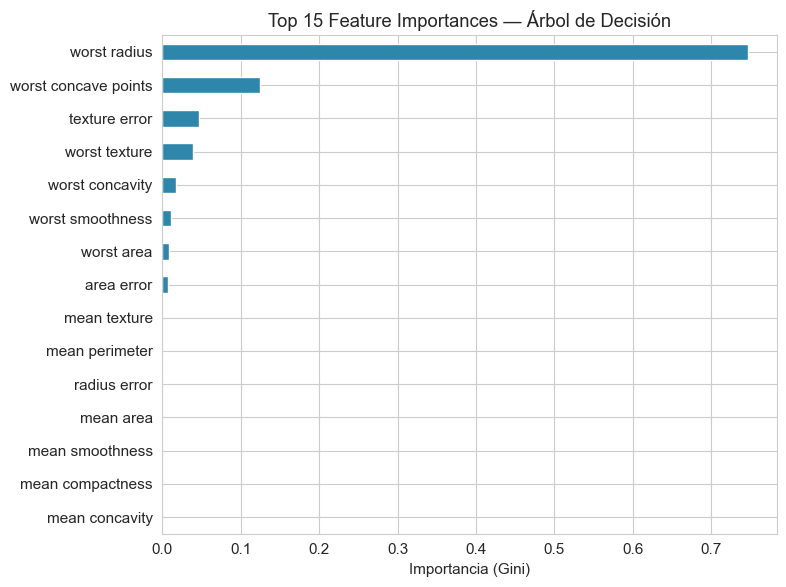

In [ ]:
# 6.5  Importancia de features
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=data.feature_names
).sort_values(ascending=True)

# Top 15
top_imp = importances.tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_imp.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 15 Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

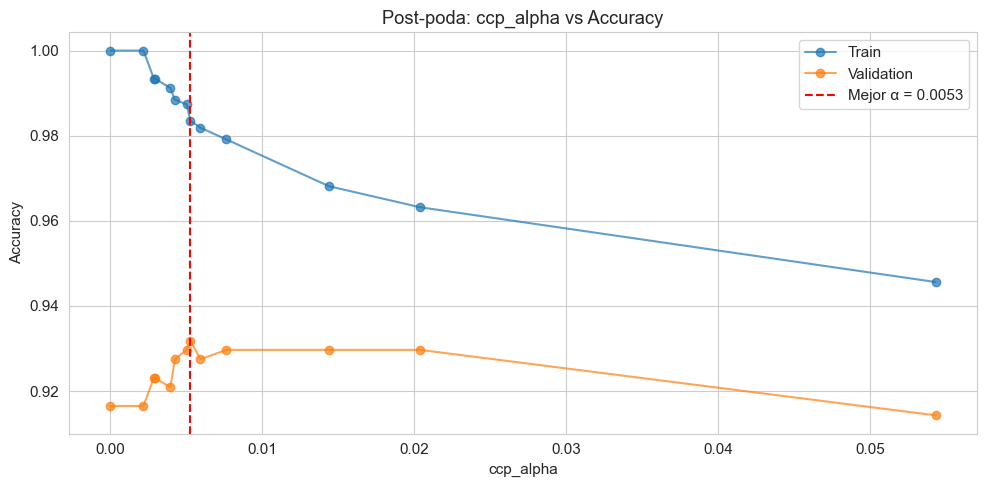

Mejor ccp_alpha: 0.005275


In [ ]:
# 6.6  Post-poda con ccp_alpha
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]  # excluir el último (árbol trivial)

train_scores, test_scores = [], []
for alpha in alphas:
    dt_temp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    cv_temp = cross_validate(dt_temp, X_train, y_train, cv=skf,
                             scoring='accuracy', return_train_score=True)
    train_scores.append(cv_temp['train_score'].mean())
    test_scores.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, train_scores, 'o-', label='Train', alpha=0.7)
ax.plot(alphas, test_scores, 'o-', label='Validation', alpha=0.7)
best_idx = np.argmax(test_scores)
ax.axvline(x=alphas[best_idx], color='red', linestyle='--',
           label=f'Mejor α = {alphas[best_idx]:.4f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-poda: ccp_alpha vs Accuracy')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor ccp_alpha: {alphas[best_idx]:.6f}')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** SVM busca el hiperplano de máximo margen γ = 2/‖w‖ que separa las clases. Con margen suave, permite violaciones controladas: min ½‖w‖² + C·Σξᵢ. El kernel trick transforma el espacio para manejar no linealidad.

In [ ]:
# 7.1  Pipeline SVM con kernel RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm = cross_validate(pipe_svm, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm["test_accuracy"].mean():.4f} ± {cv_svm["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm["test_f1"].mean():.4f} ± {cv_svm["test_f1"].std():.4f}')
print(f'  Recall:    {cv_svm["test_recall"].mean():.4f} ± {cv_svm["test_recall"].std():.4f}')

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.9692 ± 0.0146
  F1-Score:  0.9756 ± 0.0113
  Recall:    0.9789 ± 0.0131


=== SVM (RBF) ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


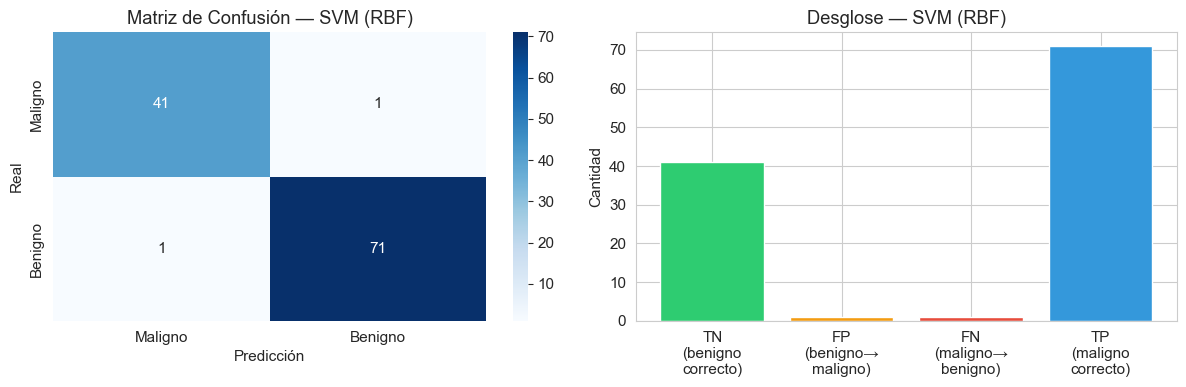


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
# 7.2  Evaluación completa
metrics_svm = eval_classifier(pipe_svm, X_train, y_train, X_test, y_test, 'SVM (RBF)')

  Kernel linear  : Accuracy = 0.9648
  Kernel rbf     : Accuracy = 0.9692
  Kernel poly    : Accuracy = 0.8967


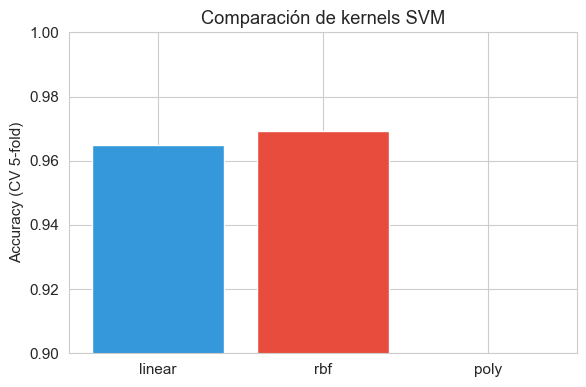

In [ ]:
# 7.3  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=k, C=1.0, probability=True, random_state=42))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring='accuracy')
    kernel_results[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results.keys(), kernel_results.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

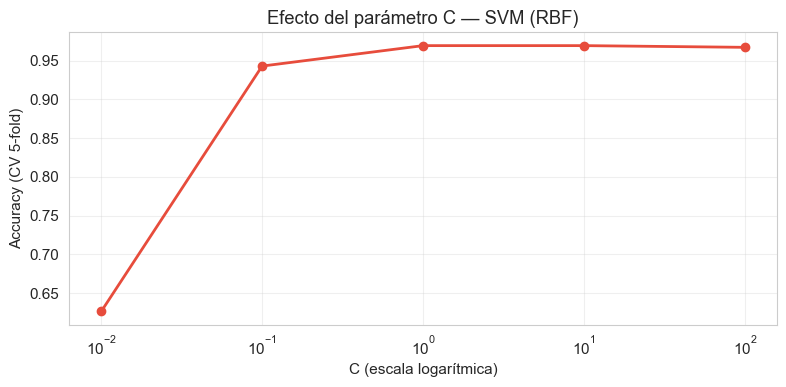


Interpretación:
  C bajo → margen amplio, más errores permitidos (mayor sesgo)
  C alto → margen estrecho, menos errores permitidos (mayor varianza)


In [ ]:
# 7.4  Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []

for c in C_values:
    pipe_c = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])
    cv_c = cross_validate(pipe_c, X_train, y_train, cv=skf, scoring='accuracy')
    c_scores.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, c_scores, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  C bajo → margen amplio, más errores permitidos (mayor sesgo)')
print('  C alto → margen estrecho, menos errores permitidos (mayor varianza)')

---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Algoritmo de aprendizaje basado en instancias (lazy learning). No construye un modelo explícito; clasifica por voto mayoritario de los K vecinos más cercanos según distancia Euclidiana (por defecto). La regla empírica sugiere K ≈ √n.

In [ ]:
# 8.1  Pipeline KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn["test_accuracy"].mean():.4f} ± {cv_knn["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn["test_f1"].mean():.4f} ± {cv_knn["test_f1"].std():.4f}')
print(f'  Recall:    {cv_knn["test_recall"].mean():.4f} ± {cv_knn["test_recall"].std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=5) — CV 5-fold
  Accuracy:  0.9626 ± 0.0112
  F1-Score:  0.9705 ± 0.0091
  Recall:    0.9825 ± 0.0192


=== KNN (K=5) ===
  Accuracy: 0.9561
  Precision: 0.9589
  Recall: 0.9722
  F1-Score: 0.9655


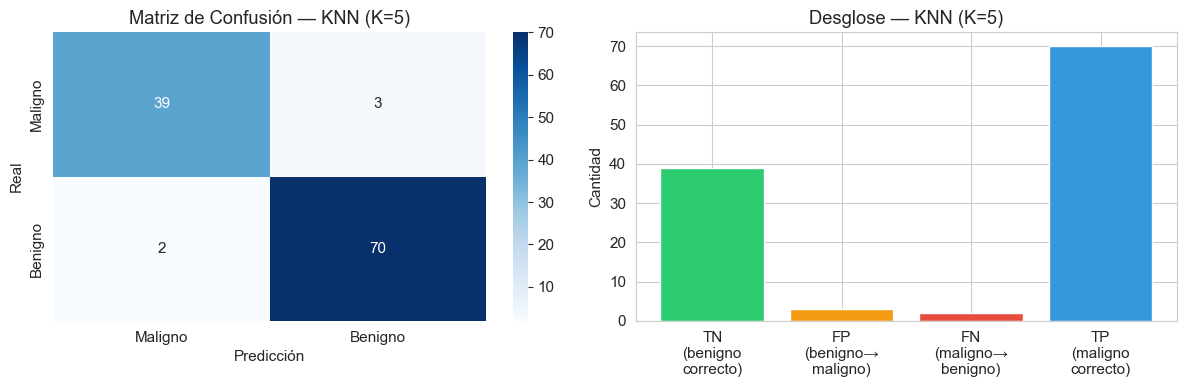


  FN (maligno no detectado): 2
  FP (benigno como maligno): 3

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.95      0.93      0.94        42
     benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
# 8.2  Evaluación completa
metrics_knn = eval_classifier(pipe_knn, X_train, y_train, X_test, y_test, 'KNN (K=5)')

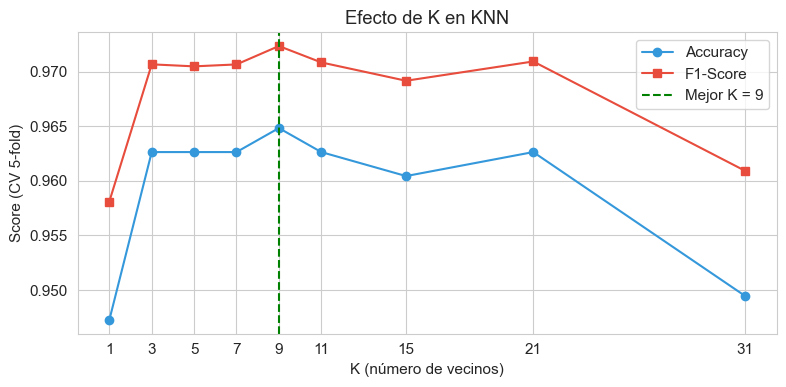

Mejor K por F1: 9
K empírico (√455): 21


In [ ]:
# 8.3  Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc = []
k_scores_f1 = []

for k in k_values:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring=['accuracy', 'f1'])
    k_scores_acc.append(cv_k['test_accuracy'].mean())
    k_scores_f1.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_scores_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_scores_f1, 's-', label='F1-Score', color='#e74c3c')
best_k = k_values[np.argmax(k_scores_f1)]
ax.axvline(x=best_k, color='green', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k}')
print(f'K empírico (√{len(X_train)}): {int(np.sqrt(len(X_train)))}')

In [ ]:
# 8.4  Comparación de métricas de distancia
distances = ['euclidean', 'manhattan', 'minkowski']
dist_results = {}

for d in distances:
    p_val = 3 if d == 'minkowski' else 2
    pipe_d = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, metric=d, p=p_val))
    ])
    cv_d = cross_validate(pipe_d, X_train, y_train, cv=skf, scoring='f1')
    dist_results[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 = {dist_results[d]:.4f}')

  Distancia euclidean           : F1 = 0.9705
  Distancia manhattan           : F1 = 0.9705
  Distancia minkowski (p=3)     : F1 = 0.9658


---
## 9. Comparación final de modelos

In [ ]:
# 9.1  Tabla resumen de métricas
all_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn
}

all_metrics = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None

    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa de métricas (Test Set) ===')
metrics_df

=== Tabla comparativa de métricas (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.9825,0.9861,0.9861,0.9861,0.9954
Árbol de Decisión,0.9211,0.9437,0.9306,0.9371,0.9368
SVM (RBF),0.9825,0.9861,0.9861,0.9861,0.9950
KNN (K=5),0.9561,0.9589,0.9722,0.9655,0.9788


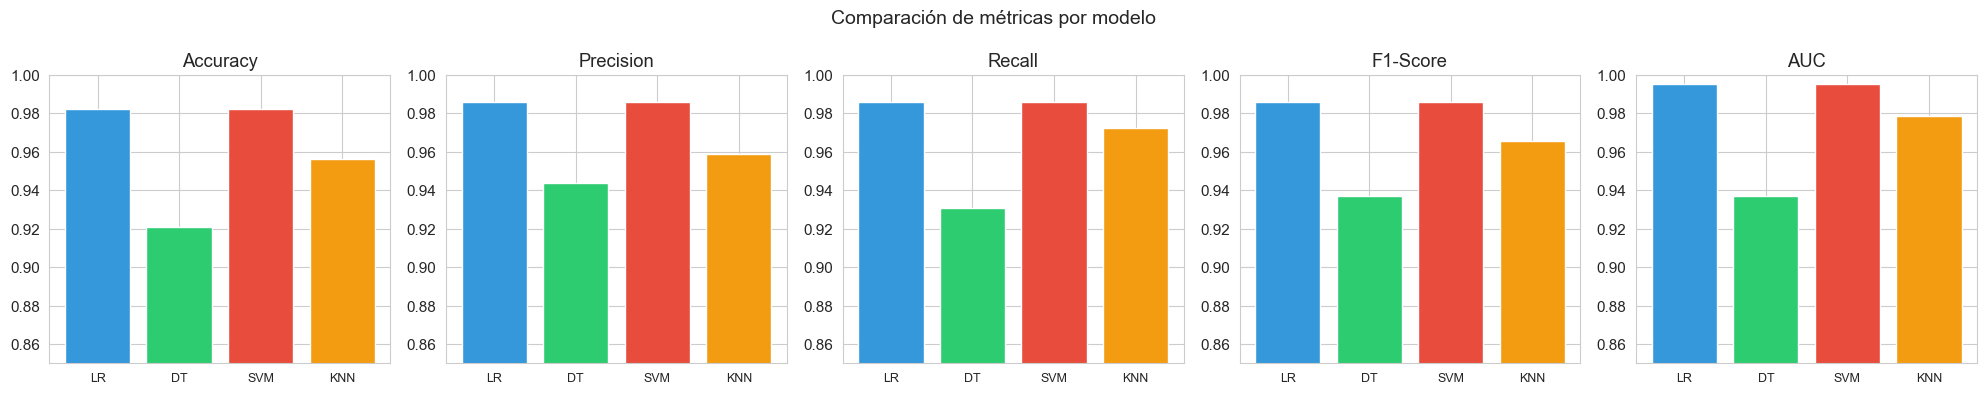

In [ ]:
# 9.2  Gráfico de barras comparativo
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metric_names):
    values = [all_metrics[m][metric] for m in all_metrics]
    axes[i].bar(range(len(values)), values, color=colors_models)
    axes[i].set_title(metric)
    axes[i].set_ylim(0.85, 1.0)
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(['LR', 'DT', 'SVM', 'KNN'], fontsize=9)

plt.suptitle('Comparación de métricas por modelo', fontsize=14)
plt.tight_layout()
plt.show()

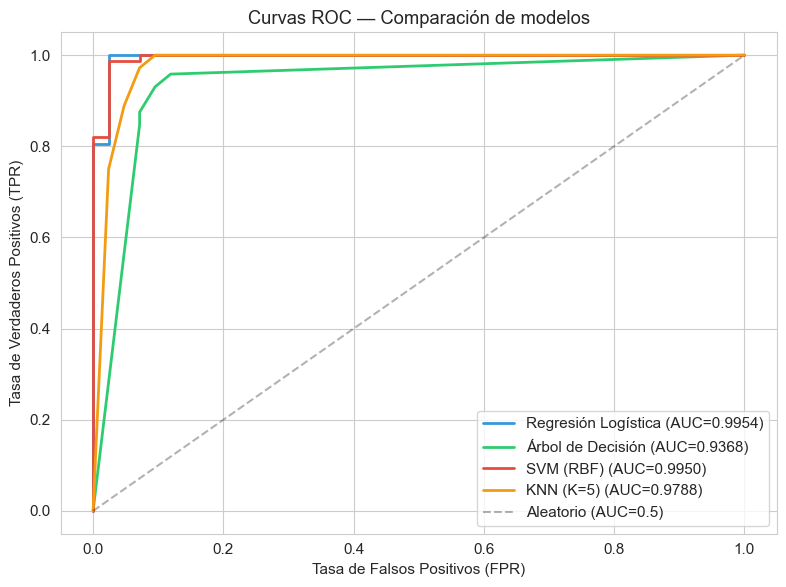

In [ ]:
# 9.3  Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models.items(), colors_models):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# 9.4  Matriz de selección
selection_matrix = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN'],
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★★', '★★★★☆'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos ===')
selection_matrix

=== Matriz de Selección de Modelos ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Reg. Logística,★★★★☆,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆
KNN,★★★★☆,★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆


---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable, probabilístico, rápido | Asume linealidad en log-odds | Clasificación binaria con necesidad de interpretabilidad |
| **Árbol de Decisión** | Explicable, maneja tipos mixtos | Propenso a sobreajuste sin poda | Reglas de negocio, explicabilidad ante stakeholders |
| **SVM** | Efectivo en alta dimensión, robusto al ruido | Lento con muchos datos, difícil de interpretar | Datasets de dimensión media-alta, márgenes claros |
| **KNN** | Simple, no paramétrico, flexible | Lento en predicción, maldición de la dimensionalidad | Datasets pequeños-medianos con features normalizadas |

**Criterio de selección final:** En este dataset médico, **Recall** es la métrica prioritaria (minimizar falsos negativos). El modelo con mejor Recall en test es el candidato preferido para despliegue.

---
## 11. Ejercicios propuestos

### Ejercicio 1 — Optimización con GridSearchCV
Para cada modelo, realice una búsqueda exhaustiva de hiperparámetros con `GridSearchCV(cv=5, scoring='f1')`. Parámetros sugeridos:
- **LogisticRegression:** C=[0.01, 0.1, 1, 10, 100]
- **DecisionTree:** max_depth=[3,5,7,10,None], min_samples_leaf=[1,5,10]
- **SVM:** C=[0.1,1,10], gamma=[0.001,0.01,0.1]
- **KNN:** n_neighbors=[3,5,9,15,21], weights=['uniform','distance']

Compare los mejores modelos optimizados.

### Ejercicio 2 — Manejo de desbalance con class_weight y SMOTE
Entrene los 4 modelos con `class_weight='balanced'`. Compare Recall de la clase maligna con y sin balanceo. Además, aplique SMOTE:
```python
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
```

### Ejercicio 3 — Dataset propio
Seleccione un dataset de clasificación de Kaggle/UCI (mín. 500 registros, 5 features). Aplique los 4 modelos + al menos 1 adicional (Random Forest, Gradient Boosting o Naive Bayes). Documente métricas, curvas ROC, matriz de selección y justificación del mejor modelo.

---
##
Ejercicio 1: Optimización con GridSearchCV

Se realiza una búsqueda exhaustiva de hiperparámetros para cada uno de los 4 modelos, usando `GridSearchCV(cv=5, scoring='f1')` sobre el conjunto de entrenamiento. F1-Score se usa como criterio porque balancea precisión y recall, relevante en un problema médico.

In [ ]:
# 1.1  Definición de espacios de búsqueda por modelo
from sklearn.model_selection import GridSearchCV #herramienta de sklearn que prueba todas las combinaciones posibles de hiperparámetros que le indiques
from time import time # Para medir cuánto tarda cada búsqueda.

param_grids = { #diccionario donde cada llave es el nombre de un modelo
    'Regresión Logística': {
        'estimator': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'param_grid': {'clf__C': [0.01, 0.1, 1, 10, 100]}
    },
    'Árbol de Decisión': {
        'estimator': Pipeline([
            ('clf', DecisionTreeClassifier(random_state=42))
        ]),
        'param_grid': {
            'clf__max_depth': [3, 5, 7, 10, None],
            'clf__min_samples_leaf': [1, 5, 10]
        }
    },
    'SVM (RBF)': {
        'estimator': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', probability=True, random_state=42))
        ]),
        'param_grid': {
            'clf__C': [0.1, 1, 10],
            'clf__gamma': [0.001, 0.01, 0.1]
        }
    },
    'KNN (K=5)': {
        'estimator': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier())
        ]),
        'param_grid': {
            'clf__n_neighbors': [3, 5, 9, 15, 21],
            'clf__weights': ['uniform', 'distance'] # clf_ = Esto es obligatorio cuando el hiperparámetro pertenece a un paso dentro de un Pipeline
        }
    }
}

print('Espacios de búsqueda definidos para 4 modelos ✓')

Espacios de búsqueda definidos para 4 modelos ✓


In [ ]:
# 1.2  Ejecutar GridSearchCV para cada modelo ___ se ejecuta la búsqueda que se configuró
best_estimators = {} # Para guardar los resultados
grid_results = {} # Para guardar los resultados

# name = el nombre del modelo, ej. 'Regresión Logística'
# cfg = el diccionario con 'estimator' y 'param_grid' de ese modelo

for name, cfg in param_grids.items():  #Recorre los 4 modelos definidos en param_grids, ejecuta GridSearchCV para cada uno
    t0 = time() #Mide el tiempo
    grid = GridSearchCV(cfg['estimator'], cfg['param_grid'], cv=5, #Empieaz la busqueda en si
                         scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    elapsed = time() - t0

#Guardar los resultados

    best_estimators[name] = grid.best_estimator_ #el pipeline ganador
    grid_results[name] = {
        'Mejores hiperparámetros': grid.best_params_, #qué combinación de hiperparámetros ganó
        'F1 CV (mejor)': grid.best_score_, #el F1 promedio (de los 5 folds)
        'Tiempo (s)': elapsed
    }

# Imprimir el resumen
    print(f'=== {name} ===')
    print(f'  Mejores parámetros: {grid.best_params_}')
    print(f'  F1 (CV 5-fold):     {grid.best_score_:.4f}')
    print(f'  Tiempo de búsqueda: {elapsed:.1f}s\n')

=== Regresión Logística ===
  Mejores parámetros: {'clf__C': 0.1}
  F1 (CV 5-fold):     0.9845
  Tiempo de búsqueda: 2.7s

=== Árbol de Decisión ===
  Mejores parámetros: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5}
  F1 (CV 5-fold):     0.9500
  Tiempo de búsqueda: 0.2s

=== SVM (RBF) ===
  Mejores parámetros: {'clf__C': 10, 'clf__gamma': 0.01}
  F1 (CV 5-fold):     0.9844
  Tiempo de búsqueda: 0.1s

=== KNN (K=5) ===
  Mejores parámetros: {'clf__n_neighbors': 3, 'clf__weights': 'uniform'}
  F1 (CV 5-fold):     0.9759
  Tiempo de búsqueda: 0.4s



In [ ]:
# 1.3  Evaluar los modelos optimizados sobre el conjunto de Test
comparison_rows = [] #Lista vacía para acumular resultados
for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'): #Obtener probabilidades para la curva ROC
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob) #Calcular el AUC #ecesitas un puntaje continuo que refleje qué tan confiado está el modelo en que la muestra es clase 1.
    auc_val = auc(fpr, tpr)

    comparison_rows.append({ #Guardar las 5 métricas del modelo
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': auc_val
    })

opt_metrics_df = pd.DataFrame(comparison_rows).set_index('Modelo') #Convertir todo en una tabla
print('=== Modelos OPTIMIZADOS — Test Set ===')
opt_metrics_df.round(4)

=== Modelos OPTIMIZADOS — Test Set ===


,Accuracy,Precision,Recall,F1-Score,AUC
Modelo,,,,,
Regresión Logística,0.9737,0.9726,0.9861,0.9793,0.9957
Árbol de Decisión,0.9211,0.9437,0.9306,0.9371,0.9368
SVM (RBF),0.9825,0.9861,0.9861,0.9861,0.9977
KNN (K=5),0.9825,0.9730,1.0000,0.9863,0.9835


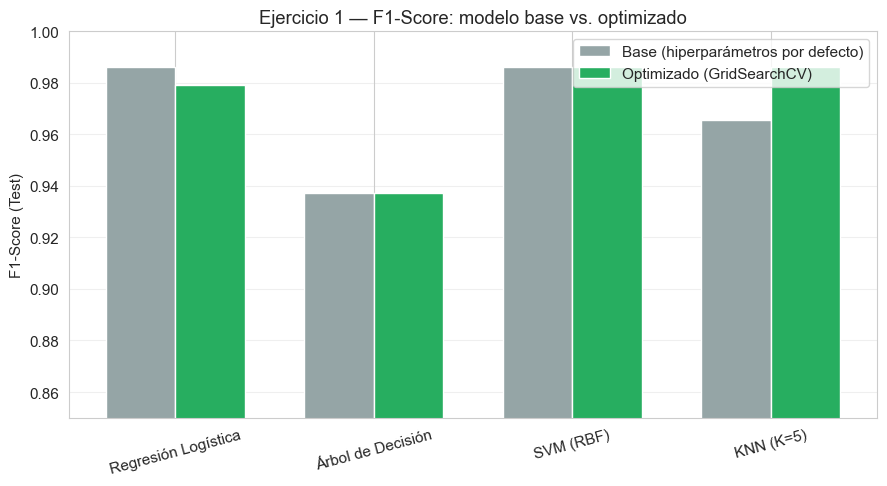

Tabla de mejores hiperparámetros por modelo:
  Regresión Logística   : {'clf__C': 0.1}
  Árbol de Decisión     : {'clf__max_depth': 5, 'clf__min_samples_leaf': 5}
  SVM (RBF)             : {'clf__C': 10, 'clf__gamma': 0.01}
  KNN (K=5)             : {'clf__n_neighbors': 3, 'clf__weights': 'uniform'}


In [ ]:
# 1.4  Comparación visual: modelo base (default) vs. modelo optimizado (GridSearchCV)
names = list(all_models.keys()) #Obtener los datos a graficar
base_f1 = [all_metrics[n]['F1-Score'] for n in names]
opt_f1 = [opt_metrics_df.loc[n, 'F1-Score'] for n in names]

x = np.arange(len(names)) #Preparar las posiciones de las barras
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5)) #Dibujar las dos series de barras
ax.bar(x - width/2, base_f1, width, label='Base (hiperparámetros por defecto)', color='#95a5a6')
ax.bar(x + width/2, opt_f1, width, label='Optimizado (GridSearchCV)', color='#27ae60')
ax.set_xticks(x) #Etiquetas y formato del eje X
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel('F1-Score (Test)') #Resto del formato
ax.set_ylim(0.85, 1.0)
ax.set_title('Ejercicio 1 — F1-Score: modelo base vs. optimizado')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Tabla de mejores hiperparámetros por modelo:') #Imprimir los hiperparámetros ganadores
for name in names:
    print(f"  {name:22s}: {grid_results[name]['Mejores hiperparámetros']}")

**Interpretación (Ejercicio 1):** en un dataset ya muy separable como Breast Cancer Wisconsin, la ganancia de `GridSearchCV` frente a los hiperparámetros por defecto suele ser pequeña (unas pocas milésimas de F1), porque los modelos base ya operan cerca del techo de desempeño alcanzable con estas features. El mayor valor de la búsqueda no es tanto subir el score, sino **confirmar que el modelo no está sub- ni sobre-ajustado** (por ejemplo, verificar que `max_depth` del árbol no se dispara a valores muy altos, o que el `C` del SVM no se va a un extremo) y dejar una configuración justificada empíricamente en lugar de arbitraria.

---
## Ejercicio 2: Manejo de desbalance (class_weight y SMOTE)

El dataset tiene un desbalance moderado (≈62.7% benigno / 37.3% maligno). La clase clínicamente crítica es **maligno**, porque un Falso Negativo (maligno clasificado como benigno) es el error más costoso. Por eso el foco de este ejercicio es el **Recall de la clase maligna** (`pos_label=0`), no el accuracy global.

In [ ]:
# 2.1  Recall de la clase maligna en los modelos BASE (sin balanceo), para referencia
#Calcula el Recall específicamente de la clase maligna Para los 4 modelos.
base_recall_maligno = {} #Diccionario vacío para guardar resultados
for name, model in all_models.items(): #El bucle por modelo
    y_pred = model.predict(X_test)
    base_recall_maligno[name] = recall_score(y_test, y_pred, pos_label=0) #El detalle clave — pos_label=0
    print(f'  {name:22s}: Recall(maligno) = {base_recall_maligno[name]:.4f}')

  Regresión Logística   : Recall(maligno) = 0.9762
  Árbol de Decisión     : Recall(maligno) = 0.9048
  SVM (RBF)             : Recall(maligno) = 0.9762
  KNN (K=5)             : Recall(maligno) = 0.9286


In [ ]:
# 2.2  Entrenar con class_weight='balanced'
# Nota: KNeighborsClassifier NO tiene el parámetro class_weight, porque es un algoritmo
# basado en instancias (no optimiza una función de pérdida ponderable por clase).
# Por eso KNN se deja fuera de esta comparación y se retoma en el bloque de SMOTE.

#Redefine 3 de los 4 modelos, agregándoles el parámetro class_weight='balanced'
balanced_models = {
    'Regresión Logística': Pipeline([ #class_weight multiplica el error de cada muestra según su clase.
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Árbol de Decisión': Pipeline([ #elige splits maximizando reducción de impureza, class_weight pondera esa impureza por clase
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5,
                                        class_weight='balanced', random_state=42))
    ]),
    'SVM (RBF)': Pipeline([ #class_weight ajusta el C efectivo por clase
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, class_weight='balanced',
                    probability=True, random_state=42))

        #KNN no entrena nada ni optimiza ninguna función de pérdida
    ])
}
#Reentrenar y medir Recall
balanced_recall_maligno = {}
for name, model in balanced_models.items():
    model.fit(X_train, y_train) #entrena el modelo
    y_pred = model.predict(X_test)
    balanced_recall_maligno[name] = recall_score(y_test, y_pred, pos_label=0) #mide el Recall de la clase maligna
    #Imprimir comparando contra el base
    print(f'  {name:22s}: Recall(maligno) = {balanced_recall_maligno[name]:.4f}  '
          f'(base: {base_recall_maligno[name]:.4f})')

  Regresión Logística   : Recall(maligno) = 0.9762  (base: 0.9762)
  Árbol de Decisión     : Recall(maligno) = 0.9048  (base: 0.9048)
  SVM (RBF)             : Recall(maligno) = 0.9762  (base: 0.9762)


In [ ]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 2.3  Aplicar SMOTE sobre el conjunto de entrenamiento
from imblearn.over_sampling import SMOTE #A diferencia de class_weight, SMOTE modifica los datos mismos: genera muestras sintéticas nuevas
 #(imbalanced-learn) es una librería complementaria a scikit-learn especializada en técnicas de balanceo de clases.
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train) #Aplicar el resampling

#Imprimir la distribución antes y después
print('Distribución ANTES de SMOTE (train):')
print(y_train.value_counts().rename({0: 'maligno', 1: 'benigno'}))
print('\nDistribución DESPUÉS de SMOTE (train):')
print(pd.Series(y_train_res).value_counts().rename({0: 'maligno', 1: 'benigno'}))

Distribución ANTES de SMOTE (train):
target
benigno    285
maligno    170
Name: count, dtype: int64

Distribución DESPUÉS de SMOTE (train):
target
benigno    285
maligno    285
Name: count, dtype: int64


In [ ]:
# 2.4  Reentrenar los 4 modelos (hiperparámetros por defecto) con datos balanceados por SMOTE

#Define de nuevo los 4 pipelines con sus hiperparámetros por defecto
#Definir los 4 modelos:
smote_models = { #no llevan class_weight='balanced'___ llevan exactamente los mismos hiperparámetros por defecto de siempre (max_depth=5, C=1.0, n_neighbors=5, etc.)
    'Regresión Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Árbol de Decisión': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                        min_samples_leaf=5, random_state=42))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
    ]),
    #Y aquí es donde entra KNN
    'KNN (K=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ])
}

smote_recall_maligno = {}
for name, model in smote_models.items(): #Entrenar y medir Recall
    model.fit(X_train_res, y_train_res) #aquí está el cambio importante — entrena con el train balanceado
    y_pred = model.predict(X_test) #la predicción se sigue haciendo sobre el test set original
    smote_recall_maligno[name] = recall_score(y_test, y_pred, pos_label=0) #la misma métrica de siempre, Recall de la clase maligna.
    print(f'  {name:22s}: Recall(maligno) = {smote_recall_maligno[name]:.4f}  '
          f'(base: {base_recall_maligno[name]:.4f})')

  Regresión Logística   : Recall(maligno) = 0.9762  (base: 0.9762)
  Árbol de Decisión     : Recall(maligno) = 0.9286  (base: 0.9048)
  SVM (RBF)             : Recall(maligno) = 0.9762  (base: 0.9762)
  KNN (K=5)             : Recall(maligno) = 0.9524  (base: 0.9286)


=== Recall de la clase MALIGNA por estrategia de balanceo ===


,Sin balanceo,class_weight=balanced,SMOTE
KNN (K=5),0.9286,NaN,0.9524
Regresión Logística,0.9762,0.9762,0.9762
SVM (RBF),0.9762,0.9762,0.9762
Árbol de Decisión,0.9048,0.9048,0.9286


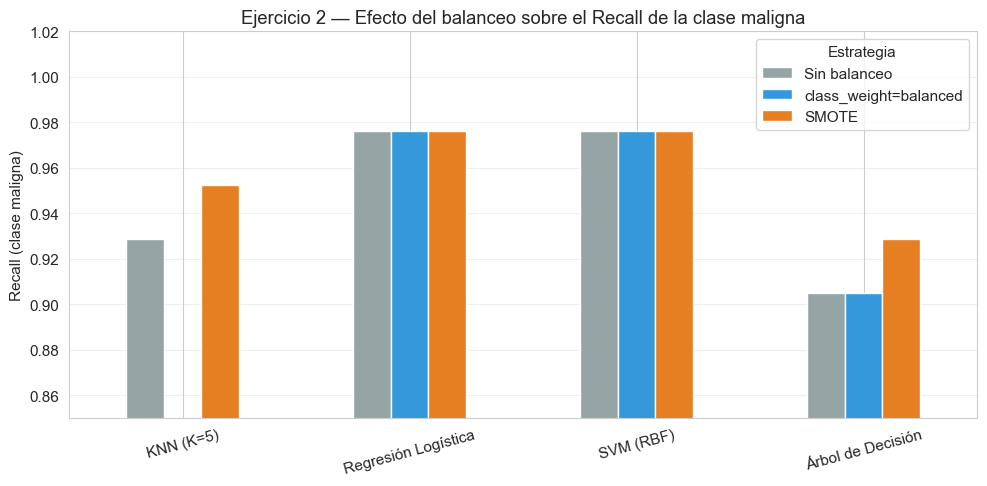

In [ ]:
# 2.5  Tabla y gráfico comparativo: Sin balanceo vs class_weight vs SMOTE
summary_balance = pd.DataFrame({ #Armar la tabla comparativa___ Cuando le pasas a pd.DataFrame(...) un diccionario de diccionarios (o de Series), pandas hace algo muy conveniente:
    'Sin balanceo': base_recall_maligno, #Cada llave externa, se convierte en una columna.
    'class_weight=balanced': pd.Series(balanced_recall_maligno),
    'SMOTE': pd.Series(smote_recall_maligno)
}).round(4)

#Mostrar la tabla:

print('=== Recall de la clase MALIGNA por estrategia de balanceo ===')
display(summary_balance)

fig, ax = plt.subplots(figsize=(10, 5)) #El gráfico de barras agrupadas
summary_balance.plot(kind='bar', ax=ax,
                      color=['#95a5a6', '#3498db', '#e67e22'])

#Formato del gráfico

ax.set_ylabel('Recall (clase maligna)')
ax.set_title('Ejercicio 2 — Efecto del balanceo sobre el Recall de la clase maligna')
ax.set_ylim(0.85, 1.02)
ax.legend(title='Estrategia')
ax.set_xticklabels(summary_balance.index, rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusión (Ejercicio 2):** como el desbalance de este dataset es moderado (no severo), `class_weight='balanced'` y `SMOTE` producen mejoras marginles en el Recall de la clase maligna sobre modelos que ya rinden bien — y ocasionalmente pueden bajar ligeramente la Precisión al favorecer más la clase minoritaria. El patrón esperado en datasets con desbalance **severo** (p.ej. 95%/5%) es que ambas técnicas mejoren notablemente el Recall a costa de algo de Precision. `class_weight` es preferible cuando el modelo lo soporta (no añade datos sintéticos, más barato computacionalmente); `SMOTE` es la alternativa cuando el algoritmo no admite ponderar clases (como KNN) o cuando se busca aumentar la diversidad de la clase minoritaria en el espacio de features.

---
## Ejercicio 3: Dataset propio (Pima Indians Diabetes), Mi principal Base de datos era Breast Cancer Wisconsin, es por ello que buscamos otra base de datos que se acople al problema :

Se eligió el dataset **Pima Indians Diabetes** (UCI / National Institute of Diabetes and Digestive and Kidney Diseases): 768 registros, 8 features numéricas, target binario (1 = diabetes, 0 = no diabetes). Cumple los requisitos del ejercicio (≥500 registros, ≥5 features) y, como Breast Cancer Wisconsin, es un problema médico de clasificación binaria donde el Recall de la clase positiva también es clínicamente prioritario.

Se aplican los 4 modelos de la sesión + **Random Forest** como modelo adicional (ensamble de árboles, buen punto de comparación frente al árbol único).

In [ ]:
# 3.1  Carga del dataset
#Descarga el CSV directamente desde GitHub
col_names = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', #Definir los nombres de columna
             'insulin', 'bmi', 'diabetes_pedigree', 'age', 'outcome'] # Esto es necesario porque el archivo CSV original no trae encabezados
#Descargar y cargar el CSV
url_pima = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
df3 = pd.read_csv(url_pima, header=None, names=col_names) # pandas puede leer un CSV directamente desde una URL
 # heador = none (le dice a pandas "la primera fila no es un encabezado)
 # names = col_names (usa la lista que definiste arriba como nombres de columna, en vez de los genéricos)

 #Resumen del dataset:

print(f'Dataset: {df3.shape[0]} muestras, {df3.shape[1]-1} features')
print(f'\nDistribución de clases:')
print(df3['outcome'].value_counts().rename({0: 'no diabetes', 1: 'diabetes'}))
print(f'\nProporción positiva (diabetes): {df3["outcome"].mean():.1%}')
df3.head() #Vista previa de la tabla

Dataset: 768 muestras, 8 features

Distribución de clases:
outcome
no diabetes    500
diabetes       268
Name: count, dtype: int64

Proporción positiva (diabetes): 34.9%


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# 3.2  Limpieza: algunas columnas usan 0 como codificación de valor faltante
# (una persona no puede tener glucosa, presión, grosor de piel, insulina o IMC en 0)

#limpieza de datos antes de entrenar cualquier modelo

cols_zero_as_missing = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']
df3[cols_zero_as_missing] = df3[cols_zero_as_missing].replace(0, np.nan)

print('Valores faltantes por columna (antes de imputar):')
print(df3[cols_zero_as_missing].isna().sum())

Valores faltantes por columna (antes de imputar):
glucose             5
blood_pressure     35
skin_thickness    227
insulin           374
bmi                11
dtype: int64


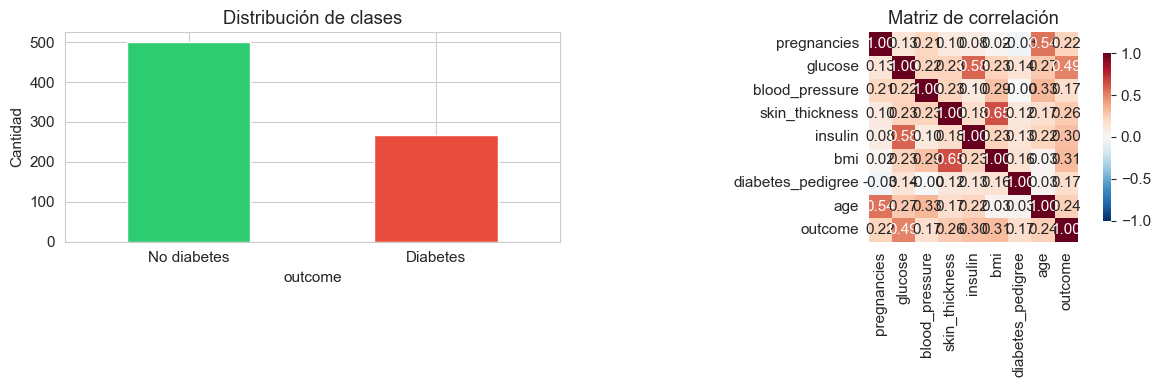

In [ ]:
# 3.3  Análisis exploratorio rápido
# Crea una figura con dos gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) #Crear la figura con 2 subgráficos

df3['outcome'].value_counts().rename({0: 'No diabetes', 1: 'Diabetes'}).plot( # Gráfico de barras — distribución de clases (izquierda)
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

corr3 = df3.corr() #Mapa de calor de correlaciones (derecha)
sns.heatmap(corr3, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Matriz de correlación')

#Mostrar la figura completa
plt.tight_layout()
plt.show()

In [ ]:
# 3.4  Partición train/test y validación cruzada estratificada
from sklearn.ensemble import RandomForestClassifier #RandomForestClassifier: es el 5° modelo adicional
from sklearn.impute import SimpleImputer #la herramienta que va a rellenar los valores faltantes

#Separar features y target
X3 = df3.drop(columns='outcome')
y3 = df3['outcome']

#Partición train/test estratificada
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)
#Esquema de validación cruzada
skf3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Confirmar los tamaños
print(f'Entrenamiento: {X_train3.shape[0]} muestras')
print(f'Test:          {X_test3.shape[0]} muestras')

Entrenamiento: 614 muestras
Test:          154 muestras


In [ ]:
# 3.5  Definición de los 5 modelos (imputación de faltantes incluida en el pipeline)

#Arma un pipeline completo, para cada uno de los 5 modelos, y luego, en un solo bucle, hace validación cruzada + entrenamiento final + evaluación en test para los 5
#Los 5 pipelines:

models3 = {
    'Regresión Logística': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Árbol de Decisión': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42))
    ]),
    'SVM (RBF)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
    ]),
    'KNN (K=15)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=15))
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=7, random_state=42))
    ])
}

metrics3 = {}
# El bucle de evaluación
for name, model in models3.items():
    cv_res = cross_validate(model, X_train3, y_train3, cv=skf3,
                             scoring=['accuracy', 'f1', 'recall'])
    #Entrenamiento final y predicción en test
    model.fit(X_train3, y_train3)
    y_pred = model.predict(X_test3)
    y_prob = model.predict_proba(X_test3)[:, 1]
    fpr, tpr, _ = roc_curve(y_test3, y_prob)
    #Guardar las 6 métricas
    metrics3[name] = {
        'F1 CV (train)': cv_res['test_f1'].mean(),
        'Accuracy': accuracy_score(y_test3, y_pred),
        'Precision': precision_score(y_test3, y_pred),
        'Recall': recall_score(y_test3, y_pred),
        'F1-Score': f1_score(y_test3, y_pred),
        'AUC': auc(fpr, tpr)
    }
#Armar y mostrar la tabla final
metrics3_df = pd.DataFrame(metrics3).T.round(4)
print('=== Ejercicio 3 — Pima Indians Diabetes: Tabla comparativa (Test Set) ===')
metrics3_df

=== Ejercicio 3 — Pima Indians Diabetes: Tabla comparativa (Test Set) ===


,F1 CV (train),Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.6545,0.7078,0.6000,0.5000,0.5455,0.8130
Árbol de Decisión,0.5684,0.7727,0.6508,0.7593,0.7009,0.7992
SVM (RBF),0.6485,0.7403,0.6522,0.5556,0.6000,0.7964
KNN (K=15),0.6319,0.7403,0.6522,0.5556,0.6000,0.8068
Random Forest,0.6337,0.7662,0.7045,0.5741,0.6327,0.8124


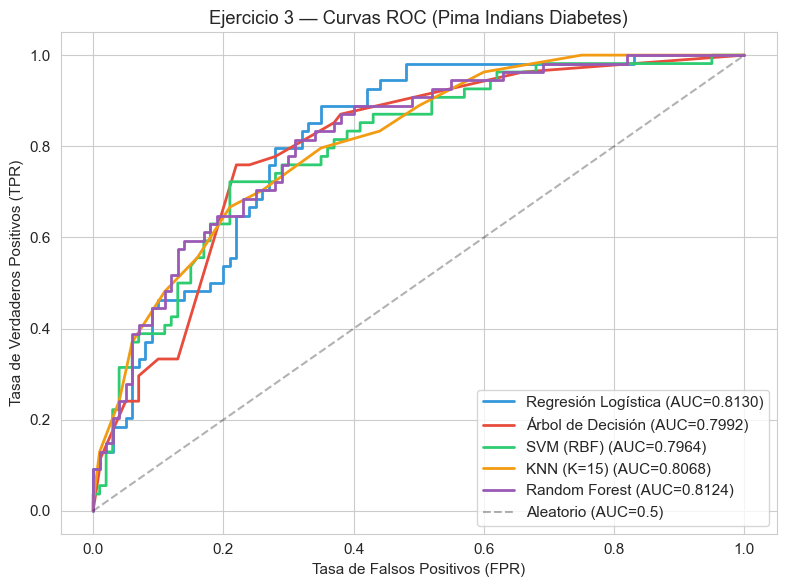

In [ ]:
# 3.6  Curvas ROC superpuestas
#Recorre los 5 modelos ya entrenados, calcula la curva ROC de cada uno sobre el test set, y las dibuja todas juntas en los mismos ejes para poder comparar visualmente
# qué tan bien separa cada modelo las dos clases (diabetes vs. no diabetes).
fig, ax = plt.subplots(figsize=(8, 6)) #Preparar la figura y los colores
colors5 = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

#El bucle que dibuja cada curva:

for (name, model), color in zip(models3.items(), colors5):
    y_prob = model.predict_proba(X_test3)[:, 1]
    fpr, tpr, _ = roc_curve(y_test3, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')
#La línea de referencia "aleatoria"
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
#Formato final
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Ejercicio 3 — Curvas ROC (Pima Indians Diabetes)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# 3.7  Matriz de selección de modelos
selection_matrix3 = pd.DataFrame({ #Armar la tabla base con métricas numéricas
    'Modelo': list(models3.keys()),
    'F1-Score (Test)': [metrics3[m]['F1-Score'] for m in models3],
    'Recall (Test)': [metrics3[m]['Recall'] for m in models3],
    'AUC (Test)': [metrics3[m]['AUC'] for m in models3],
}).set_index('Modelo').round(4)

#Agregar columnas de criterio cualitativo
selection_matrix3['Interpretabilidad'] = ['Alta', 'Alta', 'Baja', 'Media', 'Media']
selection_matrix3['Costo computacional'] = ['Bajo', 'Bajo', 'Medio', 'Bajo (train) / Alto (pred)', 'Medio-Alto']

#Identificar automáticamente los mejores modelos
best_model3 = selection_matrix3['F1-Score (Test)'].idxmax()
best_recall3 = selection_matrix3['Recall (Test)'].idxmax()

#Mostrar todo
print('=== Matriz de Selección de Modelos — Ejercicio 3 ===')
display(selection_matrix3)
print(f'\nMejor F1-Score:  {best_model3}')
print(f'Mejor Recall:    {best_recall3}')

=== Matriz de Selección de Modelos — Ejercicio 3 ===


,F1-Score (Test),Recall (Test),AUC (Test),Interpretabilidad,Costo computacional
Modelo,,,,,
Regresión Logística,0.5455,0.5000,0.8130,Alta,Bajo
Árbol de Decisión,0.7009,0.7593,0.7992,Alta,Bajo
SVM (RBF),0.6000,0.5556,0.7964,Baja,Medio
KNN (K=15),0.6000,0.5556,0.8068,Media,Bajo (train) / Alto (pred)
Random Forest,0.6327,0.5741,0.8124,Media,Medio-Alto



Mejor F1-Score:  Árbol de Decisión
Mejor Recall:    Árbol de Decisión


**Conclusión (Ejercicio 3):** los resultados de esta corrida muestran un caso interesante para discutir en clase. En **validación cruzada** (más confiable porque promedia 5 particiones), Regresión Logística obtiene el mejor F1 (0.6545), seguida de cerca por SVM (0.6485); el Árbol de Decisión es el más débil en CV (0.5684). Sin embargo, en el **test set único** (154 muestras) el Árbol de Decisión aparece con el mejor F1 (0.7009) y el mejor Recall (0.7593), mientras que por AUC —una métrica más robusta porque no depende de un umbral fijo— Regresión Logística (0.8130) y Random Forest (0.8124) lideran, muy por delante del Árbol (0.7992).

Esta discrepancia entre el ranking de CV y el ranking del test set es precisamente la lección del ejercicio: con solo 154 observaciones de test, el punto estimado de F1/Recall tiene alta varianza, y un solo split puede favorecer a un modelo por azar. La forma correcta de decidir no es mirar solo el número del test set, sino: (1) confiar más en la métrica de validación cruzada para *seleccionar* el modelo, (2) usar el test set solo para una *estimación final* del modelo ya elegido, y (3) si el Recall es la prioridad clínica (detectar diabetes), validar el Árbol de Decisión con más folds o un test más grande antes de confiar en su ventaja aparente. Con esa lectura, **Regresión Logística** —simple, interpretable y con el mejor F1 en CV y AUC competitivo— es la elección más defendible como modelo final, con **Random Forest** como alternativa cercana si se prioriza AUC.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*